# 5 — Visualización orientada a preguntas

Un gráfico no es el objetivo: es evidencia para responder una pregunta. En cada ejercicio primero escribí qué querés averiguar, luego construí la agregación y finalmente redactá una conclusión de dos o tres oraciones.

Este notebook se ejecuta manualmente **después** de que el Job termina correctamente; no forma parte del pipeline.

In [0]:
dbutils.widgets.text("student_id", "alumno01", "01 - Identificador")
dbutils.widgets.dropdown("scale", "small", ["test", "small", "demo"], "02 - Escala")

In [0]:
%run ../common/config

In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

catalog = spark.sql("SELECT current_catalog()").first()[0]
config = CourseConfig(catalog, dbutils.widgets.get("student_id"), dbutils.widgets.get("scale"))
daily = qualified_table(config, "gold_daily_sales")
risk = qualified_table(config, "gold_customer_risk")
batch = qualified_table(config, "gold_batch_summary")
for table in [daily, risk, batch]:
    assert spark.catalog.tableExists(table), f"Falta {table}. Ejecutá primero el Job completo."

## Ejemplo resuelto

**Pregunta:** ¿Qué categoría concentra el mayor monto vendido?

La agregación se hace con Spark. Sólo el resultado pequeño se convierte a Pandas para dibujarlo. Un gráfico de barras ordenado permite comparar categorías; un gráfico de torta haría más difícil comparar valores cercanos.

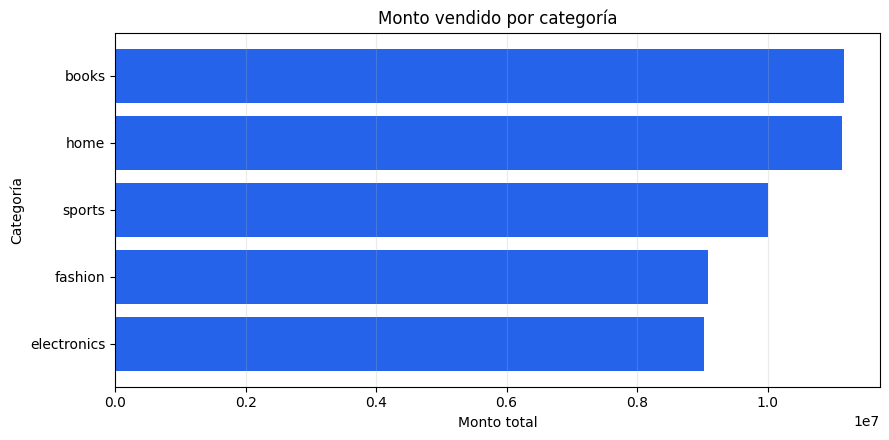

Respuesta: books es la categoría con mayor monto vendido (11,165,281.86).


In [0]:
category_sales = (spark.table(daily)
    .groupBy("category")
    .agg(F.sum("total_amount").alias("total_amount"))
    .orderBy(F.desc("total_amount")))

plot_data = category_sales.toPandas().sort_values("total_amount")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(plot_data["category"], plot_data["total_amount"], color="#2563eb")
ax.set_title("Monto vendido por categoría")
ax.set_xlabel("Monto total")
ax.set_ylabel("Categoría")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

leader = category_sales.first()
print(f"Respuesta: {leader.category} es la categoría con mayor monto vendido ({leader.total_amount:,.2f}).")

## Consigna 1 — Evolución temporal

**Pregunta:** ¿Qué día tuvo el mayor monto vendido y ese día también fue el de mayor cantidad de transacciones?

Construí una visualización temporal que permita comparar ambas métricas sin ocultar sus unidades. Explicá si los dos máximos coinciden y qué implica que coincidan —o no— sobre el ticket promedio. Fuente sugerida: `gold_daily_sales`.

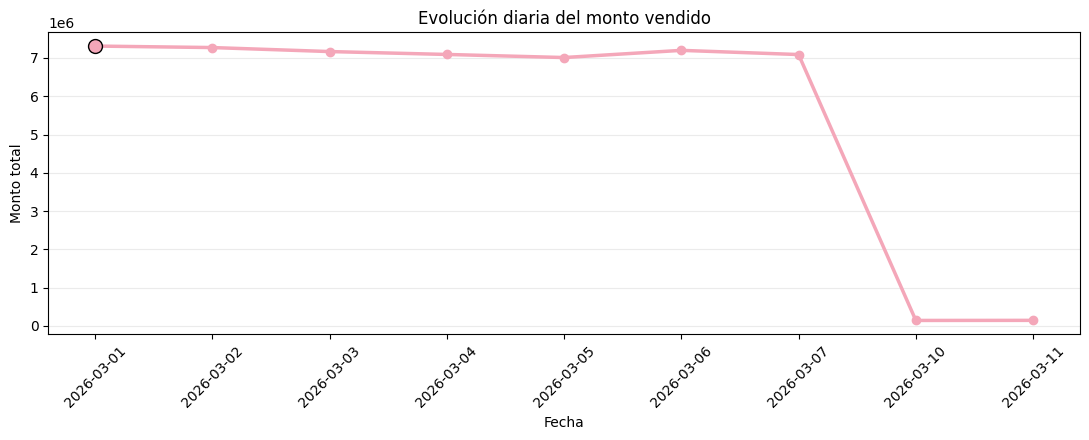

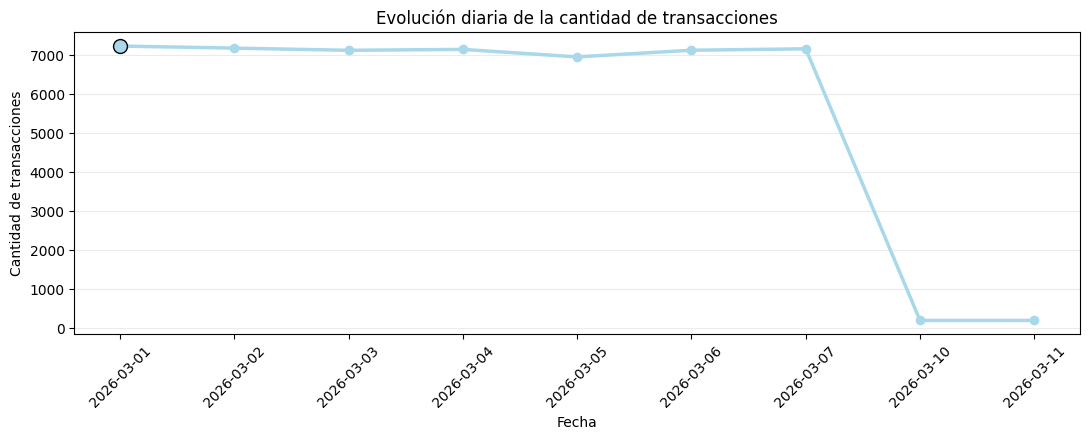

Día con mayor monto vendido: 2026-03-01
Monto máximo: 7,310,840.77
Día con mayor cantidad de transacciones: 2026-03-01
Cantidad máxima de transacciones: 7,236
Los dos máximos coinciden.


In [0]:
# Tu solución. Agregá por sale_date antes de convertir el resultado a Pandas.
# Incluí título, ejes, unidades y una respuesta escrita.

evolucion = (
    spark.table(daily)
    .groupBy("sale_date")
    .agg(
        F.sum("total_amount").alias("monto_total"),
        F.sum("transaction_count").alias("cantidad_transacciones")
    )
    .orderBy("sale_date")
)

plot_data = evolucion.toPandas()
plot_data["sale_date"] = plot_data["sale_date"].astype(str)

# Identificamos los máximos
idx_monto = plot_data["monto_total"].idxmax()
idx_trans = plot_data["cantidad_transacciones"].idxmax()

dia_max_monto = plot_data.loc[idx_monto, "sale_date"]
monto_max = plot_data.loc[idx_monto, "monto_total"]

dia_max_trans = plot_data.loc[idx_trans, "sale_date"]
trans_max = plot_data.loc[idx_trans, "cantidad_transacciones"]

# Colores cute
rosa_pastel = "#F4A7B9"
celeste_pastel = "#A8D8EA"

# monto vendido
fig, ax = plt.subplots(figsize=(11, 4.5))

ax.plot(
    plot_data["sale_date"],
    plot_data["monto_total"],
    marker="o",
    linewidth=2.5,
    color=rosa_pastel
)

ax.scatter(
    dia_max_monto,
    monto_max,
    s=100,
    color=rosa_pastel,
    edgecolor="black",
    zorder=5
)

ax.set_title("Evolución diaria del monto vendido")
ax.set_xlabel("Fecha")
ax.set_ylabel("Monto total")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()


# cantidad de transacciones
fig, ax = plt.subplots(figsize=(11, 4.5))

ax.plot(
    plot_data["sale_date"],
    plot_data["cantidad_transacciones"],
    marker="o",
    linewidth=2.5,
    color=celeste_pastel
)

ax.scatter(
    dia_max_trans,
    trans_max,
    s=100,
    color=celeste_pastel,
    edgecolor="black",
    zorder=5
)

ax.set_title("Evolución diaria de la cantidad de transacciones")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de transacciones")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()


print(f"Día con mayor monto vendido: {dia_max_monto}")
print(f"Monto máximo: {monto_max:,.2f}")
print(f"Día con mayor cantidad de transacciones: {dia_max_trans}")
print(f"Cantidad máxima de transacciones: {trans_max:,.0f}")

if dia_max_monto == dia_max_trans:
    print("Los dos máximos coinciden.")
else:
    print("Los dos máximos NO coinciden.")

RTA :

El 1 de marzo de 2026 fue el día con mayor monto vendido, alcanzando 7.310.840,77 y también registró la mayor cantidad de transacciones, con 7.236 operaciones. Por lo tanto, ambos máximos coinciden. Esto sugiere que el mayor volumen de ventas de ese día estuvo principalmente asociado a una mayor cantidad de operaciones y no necesariamente a un incremento del ticket promedio.

## Consigna 2 — Canal y fraude

**Pregunta:** ¿Qué canal de pago presenta la mayor tasa de fraude? ¿La conclusión se sostiene al considerar el número de transacciones de cada canal?

Mostrá tasa y volumen de manera legible. No compares sólo cantidades de fraude: calculá el denominador correcto. Fuente sugerida: `gold_daily_sales`.

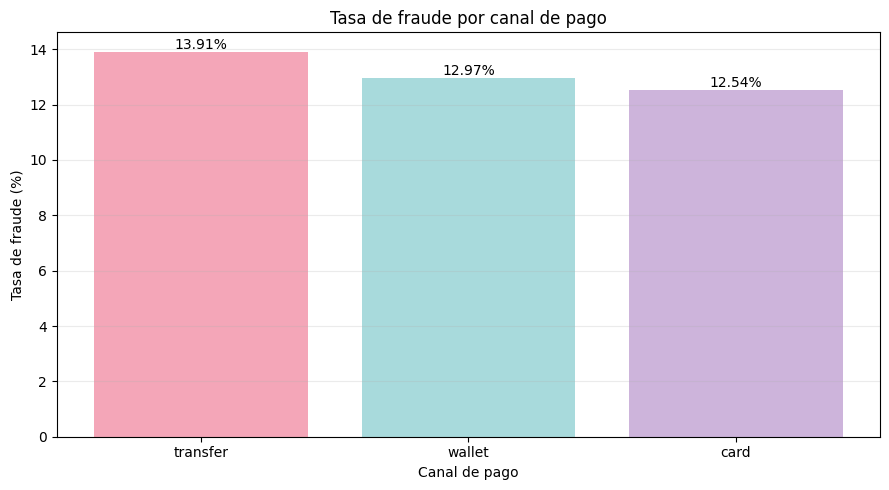

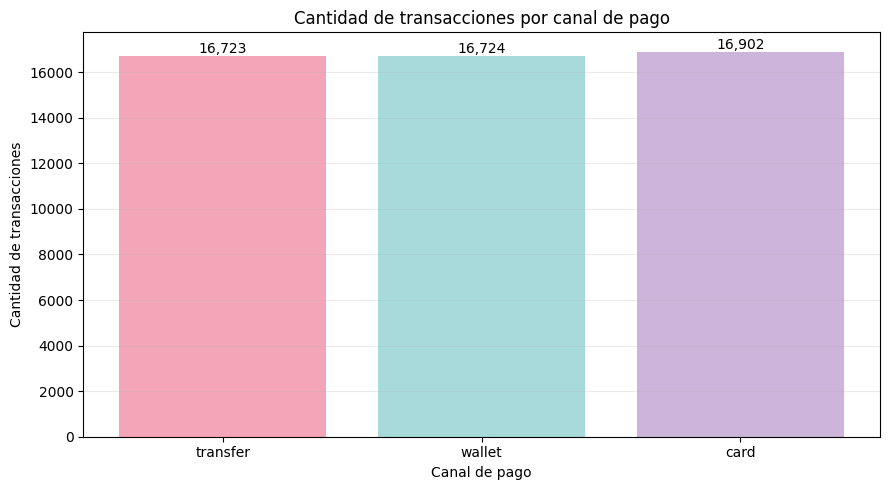

Canal con mayor tasa de fraude: transfer
Tasa de fraude: 13.91%
Transacciones del canal: 16,723
Transacciones fraudulentas: 2,327


In [0]:
# Tu solución. Recalculá la tasa global como suma(fraud_transactions) / suma(transaction_count).
# Evitá promediar directamente fraud_rate entre grupos.

from pyspark.sql import functions as F
import matplotlib.pyplot as plt

fraude_canal = (
    spark.table(daily)
    .groupBy("payment_channel")
    .agg(
        F.sum("fraud_transactions").alias("fraud_transactions"),
        F.sum("transaction_count").alias("transaction_count")
    )
    .withColumn(
        "fraud_rate",
        F.col("fraud_transactions") / F.col("transaction_count")
    )
    .orderBy(F.desc("fraud_rate"))
)

plot_data = fraude_canal.toPandas()

colores = ["#F4A6B8", "#A8DADC", "#CDB4DB", "#FFD6A5", "#BDE0FE"]

#Fraud

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    plot_data["payment_channel"],
    plot_data["fraud_rate"] * 100,
    color=colores[:len(plot_data)]
)

ax.set_title("Tasa de fraude por canal de pago")
ax.set_xlabel("Canal de pago")
ax.set_ylabel("Tasa de fraude (%)")
ax.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, plot_data["fraud_rate"] * 100):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


#volumen

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    plot_data["payment_channel"],
    plot_data["transaction_count"],
    color=colores[:len(plot_data)]
)

ax.set_title("Cantidad de transacciones por canal de pago")
ax.set_xlabel("Canal de pago")
ax.set_ylabel("Cantidad de transacciones")
ax.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, plot_data["transaction_count"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()



lider = fraude_canal.first()

print(f"Canal con mayor tasa de fraude: {lider.payment_channel}")
print(f"Tasa de fraude: {lider.fraud_rate * 100:.2f}%")
print(f"Transacciones del canal: {lider.transaction_count:,}")
print(f"Transacciones fraudulentas: {lider.fraud_transactions:,}")

RTA:
El canal transfer presenta la mayor tasa de fraude, con un 13,91%, seguido por wallet (12,97%) y card (12,54%). Los tres canales tienen volúmenes de transacciones muy similares por lo que la mayor tasa observada en transfer no se explica por una diferencia importante en el tamaño de los grupos y la conclusión se mantiene al considerar el volumen.

## Consigna 3 — Concentración geográfica y de producto

**Pregunta:** ¿Qué combinación de país y categoría genera el mayor monto? ¿Existe una categoría dominante en todos los países o cambia según el mercado?

Elegí una visualización que permita comparar simultáneamente países y categorías. Justificá brevemente por qué ese tipo de gráfico es adecuado. Fuente sugerida: `gold_daily_sales`.

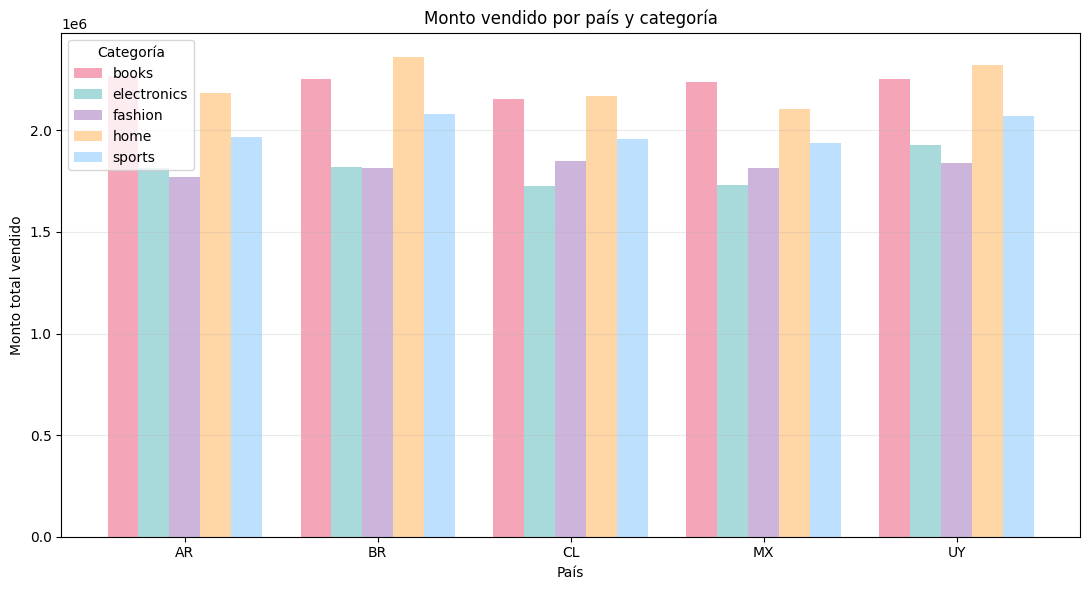

Mayor combinación global: BR - home
Monto total: 2,361,959.97

Categoría dominante por país:
+-------+--------+------------+
|country|category|total_amount|
+-------+--------+------------+
|AR     |books   |2267722.26  |
|BR     |home    |2361959.97  |
|CL     |home    |2167748.03  |
|MX     |books   |2235941.63  |
|UY     |home    |2323924.46  |
+-------+--------+------------+



In [0]:
# Tu solución. Algunas opciones: mapa de calor o barras agrupadas.
# La conclusión debe mencionar tanto el máximo global como las diferencias entre países.


from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import numpy as np


pais_categoria = (
    spark.table(daily)
    .groupBy("country", "category")
    .agg(
        F.sum("total_amount").alias("total_amount")
    )
)


plot_data = pais_categoria.toPandas()


pivot = (
    plot_data
    .pivot(index="country", columns="category", values="total_amount")
    .fillna(0)
)

colores = [
    "#F4A6B8",  
    "#A8DADC",  
    "#CDB4DB",  
    "#FFD6A5",  
    "#BDE0FE",  
    "#B7E4C7"   
]



fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(pivot.index))
n_cat = len(pivot.columns)
width = 0.8 / n_cat

for i, categoria in enumerate(pivot.columns):
    ax.bar(
        x + (i - (n_cat - 1) / 2) * width,
        pivot[categoria],
        width,
        label=categoria,
        color=colores[i % len(colores)]
    )

ax.set_title("Monto vendido por país y categoría")
ax.set_xlabel("País")
ax.set_ylabel("Monto total vendido")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.legend(title="Categoría")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


lider_global = pais_categoria.orderBy(
    F.desc("total_amount")
).first()

print(
    f"Mayor combinación global: "
    f"{lider_global.country} - {lider_global.category}"
)

print(
    f"Monto total: {lider_global.total_amount:,.2f}"
)

from pyspark.sql.window import Window

w = Window.partitionBy("country").orderBy(F.desc("total_amount"))

lideres_pais = (
    pais_categoria
    .withColumn("ranking", F.row_number().over(w))
    .filter(F.col("ranking") == 1)
    .select("country", "category", "total_amount")
    .orderBy("country")
)

print("\nCategoría dominante por país:")
lideres_pais.show(truncate=False)

RTA

La combinación de Brasil y la categoría home genera el mayor monto vendido, con un total de 2.361.959,97. No existe una única categoría dominante en todos los países: home lidera en Brasil, Chile y Uruguay, mientras que books presenta el mayor monto en Argentina y México. Esto indica que la categoría de mayor peso cambia según el mercado.

Y con respecto al tipo de gráfico las barras agrupadas permiten comparar simultáneamente los países y las categorías y detectar visualmente las diferencias entre mercados. 

## Consigna 4 — Calidad del pipeline

**Pregunta:** ¿Qué proporción de cada lote fue aceptada y rechazada? ¿El lote nuevo presenta una calidad diferente del lote inicial?

Compará lotes usando proporciones además de cantidades absolutas. Señalá cualquier limitación de comparar lotes de tamaños distintos. Fuente sugerida: `gold_batch_summary`.

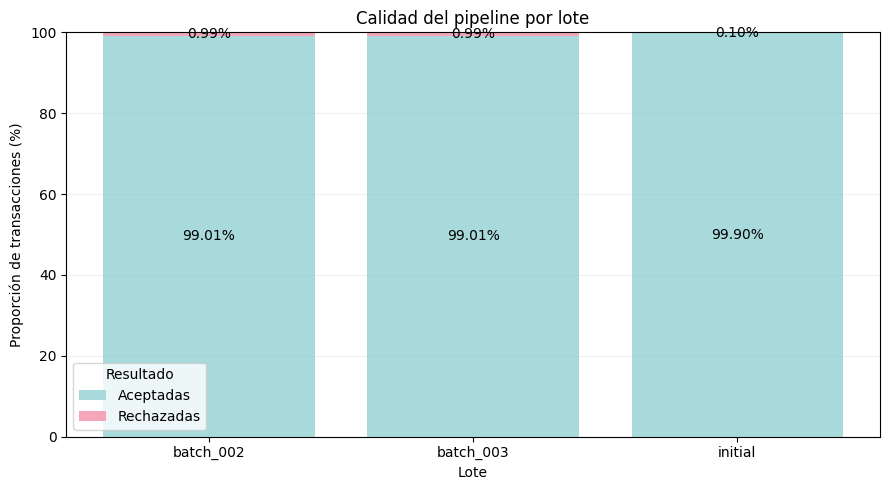

Lote: batch_002
  Total: 202
  Aceptadas: 200 (99.01%)
  Rechazadas: 2 (0.99%)

Lote: batch_003
  Total: 203
  Aceptadas: 201 (99.01%)
  Rechazadas: 2 (0.99%)

Lote: initial
  Total: 49,999
  Aceptadas: 49,948 (99.90%)
  Rechazadas: 51 (0.10%)



In [0]:
# Tu solución. Calculá total = accepted_transactions + rejected_transactions.
# Un gráfico de barras apiladas al 100% puede facilitar la comparación de proporciones.

from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import numpy as np

calidad = (
    spark.table(batch)
    .select(
        "source_batch_id",
        "accepted_transactions",
        "rejected_transactions"
    )
    .withColumn(
        "total_transactions",
        F.col("accepted_transactions") + F.col("rejected_transactions")
    )
    .withColumn(
        "accepted_rate",
        F.col("accepted_transactions") / F.col("total_transactions")
    )
    .withColumn(
        "rejected_rate",
        F.col("rejected_transactions") / F.col("total_transactions")
    )
    .orderBy("source_batch_id")
)


plot_data = calidad.toPandas()

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(plot_data))

ax.bar(
    x,
    plot_data["accepted_rate"] * 100,
    label="Aceptadas",
    color="#A8DADC"
)

ax.bar(
    x,
    plot_data["rejected_rate"] * 100,
    bottom=plot_data["accepted_rate"] * 100,
    label="Rechazadas",
    color="#F4A6B8"
)

for i in range(len(plot_data)):

    accepted = plot_data.loc[i, "accepted_rate"] * 100
    rejected = plot_data.loc[i, "rejected_rate"] * 100

    ax.text(
        i,
        accepted / 2,
        f"{accepted:.2f}%",
        ha="center",
        va="center"
    )

    ax.text(
        i,
        accepted + rejected / 2,
        f"{rejected:.2f}%",
        ha="center",
        va="center"
    )

ax.set_title("Calidad del pipeline por lote")
ax.set_xlabel("Lote")
ax.set_ylabel("Proporción de transacciones (%)")
ax.set_xticks(x)
ax.set_xticklabels(plot_data["source_batch_id"])
ax.set_ylim(0, 100)
ax.legend(title="Resultado")
ax.grid(axis="y", alpha=0.20)

plt.tight_layout()
plt.show()



for _, row in plot_data.iterrows():

    print(f"Lote: {row['source_batch_id']}")
    print(f"  Total: {int(row['total_transactions']):,}")
    print(f"  Aceptadas: {int(row['accepted_transactions']):,} "
          f"({row['accepted_rate'] * 100:.2f}%)")
    print(f"  Rechazadas: {int(row['rejected_transactions']):,} "
          f"({row['rejected_rate'] * 100:.2f}%)")
    print()

RTA:

batch_002 y batch_003 presentan prácticamente la misma calidad, con una tasa de aceptación del 99,01% y de rechazo del 0,99%. El lote inicial presenta una aceptación ligeramente superior, del 99,90%. Sin embargo, esta comparación debe interpretarse considerando la gran diferencia de tamaño entre los lotes: el inicial contiene 49.999 transacciones, mientras que los nuevos contienen apenas 202 y 203, por lo que pequeñas variaciones en los rechazos tienen un impacto porcentual mucho mayor en estos últimos.

## Criterios de entrega

Para cada consigna entregá: (1) la transformación de datos, (2) un gráfico, y (3) una conclusión de dos o tres oraciones que responda explícitamente la pregunta.

Cada gráfico debe tener título informativo, ejes y unidades legibles, categorías ordenadas cuando corresponda y una elección de color que no sea la única forma de comunicar el significado. No conviertas una tabla Silver completa a Pandas: agregá primero con Spark y convertí sólo el resultado pequeño.